# 2D-1D wavelet deconvolution of a dirty ALMA spectral cube -- vs. CLEAN, soft vs. hard

Goes from a dirty-beam-convolved, noisy ALMA-like cube to a "clean" cube
using the `Deconvolver2D1D` sparse-recovery algorithm in `src/deconvolver.py`
-- a deconvolution counterpart of the `Denoiser2D1D` denoiser from
[`Denoiser2D1D-improved`](../../Denoiser2D1D-improved), built on the same
kind of 2D (spatial) x 1D (spectral) wavelet dictionary, but solving
`Y = H(X) + N` (dirty beam convolution) instead of `Y = X + N` (pure noise).
See the repo `README.md` for the full derivation of what has to change
between the two, including two non-obvious pitfalls encountered while
building this: the interferometer's missing zero-spacing flux, and how
noise-level calibration has to route through the beam.

Also runs a from-scratch classic **Hogbom CLEAN** (`src/clean.py`) on the
same dirty cube as a baseline, so the two can be compared directly:
Dirac-delta (point-source) component fitting, per channel independently,
vs. a single joint 2D-1D-wavelet-sparse fit across the whole cube at once.

This notebook:
1. builds a toy, spatially-varying (non-stationary) spectral cube: a single
   rotating ring that splits into two spatially separated blobs in most
   velocity channels due to its kinematics,
2. builds a toy but structurally real ALMA-like dirty beam from a mock
   antenna layout and simulated Earth-rotation synthesis,
3. convolves + adds noise to get a dirty cube, and shows the dirty beam and
   dirty central channel,
4. runs the 2D-1D wavelet deconvolution and classic Hogbom CLEAN, and
   compares true / dirty / CLEAN / 2D-1D-wavelet channel maps side by side.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import matplotlib.pyplot as plt

from toy_cube import rotating_ring_cube, count_blobs
from psf import mock_alma_dirty_beam_rings, beam_fwhm_pixels
from deconvolver import Deconvolver2D1D, convolve_cube
from clean import hogbom_clean_cube, restore_clean_cube

np.random.seed(0)
plt.rcParams['figure.facecolor'] = 'white'

## 1. Toy non-stationary rotating-ring cube

The line-of-sight velocity at each point on the ring is `v_los = v_max *
sin(theta)`, i.e. it depends on spatial position (`theta`, the azimuthal
angle around the ring) -- the spectral line profile is *not* the same shape
everywhere in the field of view. At a fixed channel velocity `v0`, only the
two points on the ring where `v_los(theta) = v0` are bright, so a single,
spatially connected source shows up as two separated blobs in most
channels, merging into one only at the rotation curve's extremes (top/bottom
of the ring).

cube shape (nz, ny, nx) = (41, 80, 80)
true total flux = 874.6
peak brightness  = 0.9934


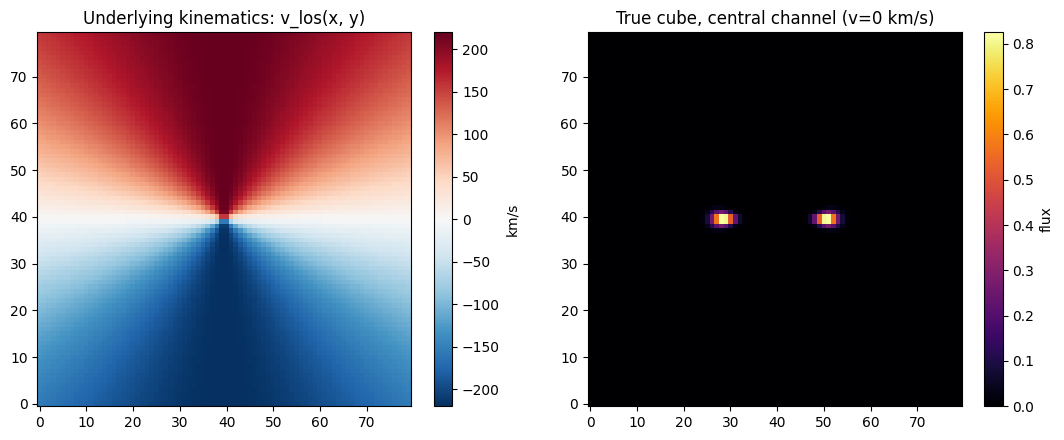

In [2]:
cube, velocities, v_los = rotating_ring_cube(
    nz=41, ny=80, nx=80, v_max=220.0, line_sigma=18.0,
    ring_radius=11.0, ring_sigma=1.6, peak_flux=1.0,
)
nz, ny, nx = cube.shape
center_channel = nz // 2
print(f'cube shape (nz, ny, nx) = {cube.shape}')
print(f'true total flux = {cube.sum():.4g}')
print(f'peak brightness  = {cube.max():.4g}')

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
im0 = axs[0].imshow(v_los, origin='lower', cmap='RdBu_r')
axs[0].set_title('Underlying kinematics: v_los(x, y)')
plt.colorbar(im0, ax=axs[0], label='km/s', fraction=0.046)

im1 = axs[1].imshow(cube[center_channel], origin='lower', cmap='inferno')
axs[1].set_title(f'True cube, central channel (v={velocities[center_channel]:.0f} km/s)')
plt.colorbar(im1, ax=axs[1], label='flux', fraction=0.046)
plt.tight_layout()
plt.show()

In [3]:
# Quick scan: how many spatially separated blobs does the true source show
# in each channel? (0.3x that channel's own peak, dependency-free
# connected-components count from toy_cube.count_blobs)
print(f"{'chan':>4} {'v (km/s)':>9} {'peak':>7} {'n_blobs':>7}")
for k in range(0, nz, 4):
    peak = cube[k].max()
    n_blobs, _ = count_blobs(cube[k], 0.3 * peak) if peak > 1e-6 else (0, None)
    print(f'{k:4d} {velocities[k]:9.0f} {peak:7.3f} {n_blobs:7d}')

chan  v (km/s)    peak n_blobs
   0      -286   0.001       1
   4      -229   0.841       1
   8      -172   0.968       2
  12      -114   0.973       2
  16       -57   0.934       2
  20         0   0.825       2
  24        57   0.934       2
  28       114   0.973       2
  32       172   0.968       2
  36       229   0.841       1
  40       286   0.001       1


## 2. Toy ALMA-like dirty beam

Built from an actual (mock) antenna layout and simulated Earth-rotation
aperture synthesis, not hand-drawn: antenna positions -> baseline vectors
for every antenna pair at several array rotation angles -> grid the
resulting (u, v) points -> the dirty beam is the inverse FFT of that
sampling function. Because baselines always occur as (i, j)/(j, i) +/- pairs,
the sampling function -- and hence the beam -- is exactly centro-symmetric,
which is also why the beam's convolution operator can be reused as its own
adjoint in the deconvolution's gradient step (see `deconvolver.py`).

Antennas are placed on a handful of discrete concentric rings
(`psf.ring_antenna_layout`) rather than at continuously random radii. With
only a few distinct baseline-length "shells" -- especially once rotated
through many hour angles -- the (u, v) coverage is close to a few nearly-
fully-sampled annuli, and the dirty beam of a set of annuli is a sum of
Bessel-J0-like concentric rings: this is what gives real ALMA dirty beam
images their characteristic target/fringe pattern (as opposed to the more
speckled sidelobe field a fully random antenna layout produces).

In [4]:
beam, sampling, (ant_x, ant_y), (u, v) = mock_alma_dirty_beam_rings(
    n_rings=4, antennas_per_ring=7, max_radius=100.0, jitter=0.03,
    hour_angles_deg=np.linspace(-90, 90, 25),
    grid_size=81, natural_weighting=False, seed=3,
)
print(f'beam shape = {beam.shape}, peak = {beam.max():.3f}')
print(f'beam.sum() = {beam.sum():.3e}  <-- ~0: no zero-length baseline is ever measured,')
print('               so the dirty beam has essentially zero DC (total-flux) response.')
print(f'uv sampling fill fraction = {(sampling > 0).mean():.3f}')
print(f'main-lobe FWHM ~ {beam_fwhm_pixels(beam):.1f} pixels')
print(f'beam is centro-symmetric: {np.allclose(beam, beam[::-1, ::-1])}')

beam shape = (81, 81), peak = 1.000
beam.sum() = 4.441e-16  <-- ~0: no zero-length baseline is ever measured,
               so the dirty beam has essentially zero DC (total-flux) response.
uv sampling fill fraction = 0.465
main-lobe FWHM ~ 2.0 pixels
beam is centro-symmetric: True


## 3. Dirty cube = true cube (*) dirty beam -- no noise added

Convolve every channel of the true cube with the same dirty beam (FFT-based,
`deconvolver.convolve_cube`). No noise is added here: this isolates the
effect of the dirty beam alone (sidelobes/incomplete uv coverage) from
thermal-noise effects, which were covered separately in the earlier,
noisy version of this comparison. `Deconvolver2D1D` and `hogbom_clean_cube`
both still need *some* nominal detection-threshold scale to know when to
stop absorbing structure into the model -- `sigma_noise` below is that small
nominal scale, not a real noise level (there isn't one in this cube).

In [5]:
dirty_cube = convolve_cube(cube, beam)  # PSF-convolved, no noise added

sigma_noise = 0.005 * dirty_cube.max()  # nominal threshold scale only, see note above
print(f'dirty cube min/max = {dirty_cube.min():.3g} / {dirty_cube.max():.3g}')
print(f'(true cube min/max was {cube.min():.3g} / {cube.max():.3g} -- note the dirty map')
print(' goes negative and its total flux can even go negative: classic dirty-beam sidelobe')
print(' bowls plus the missing zero-spacing flux discussed in the README.')
print(f'true total flux = {cube.sum():.4g}, dirty total flux = {dirty_cube.sum():.4g}')

dirty cube min/max = -0.362 / 1.81
(true cube min/max was 4.11e-302 / 0.993 -- note the dirty map
 goes negative and its total flux can even go negative: classic dirty-beam sidelobe
 bowls plus the missing zero-spacing flux discussed in the README.
true total flux = 874.6, dirty total flux = -139


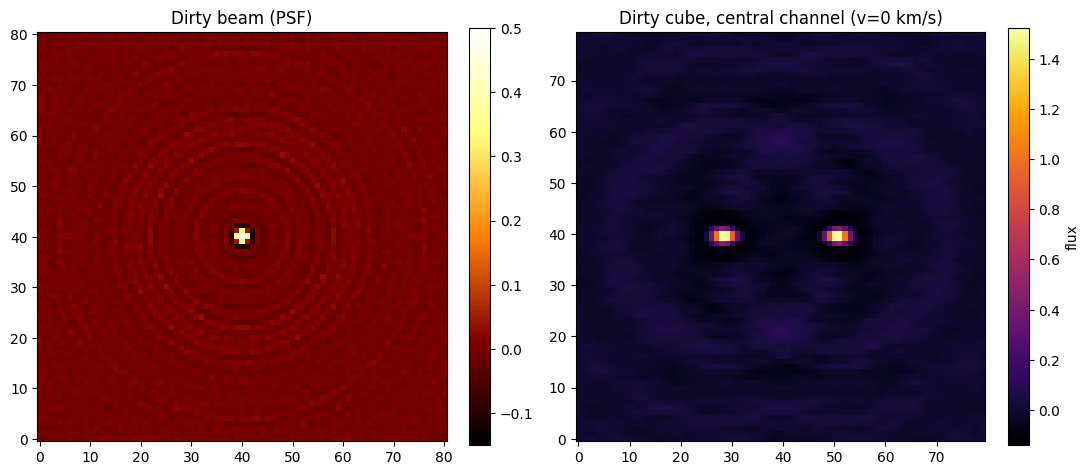

In [6]:
# --- Required figure: dirty PSF and the dirty central channel, one figure, subplots ---
fig, axs = plt.subplots(1, 2, figsize=(11, 4.8))

im0 = axs[0].imshow(beam, origin='lower', cmap='afmhot', vmin=-0.15, vmax=0.5)
axs[0].set_title('Dirty beam (PSF)')
plt.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(dirty_cube[center_channel], origin='lower', cmap='inferno')
axs[1].set_title(f'Dirty cube, central channel (v={velocities[center_channel]:.0f} km/s)')
plt.colorbar(im1, ax=axs[1], fraction=0.046, label='flux')

plt.tight_layout()
plt.show()

In [8]:
print(beam.max())

1.0


## 4. Two deconvolution methods on the same dirty cube

**Classic Hogbom CLEAN** (`src/clean.py`): iteratively finds the brightest
residual pixel, subtracts a small (`gain`) fraction of the dirty beam
recentered there, and repeats down to a noise-based stopping threshold --
run completely independently, channel by channel (CLEAN has no notion of
the spectral axis). The final "restored" image is the delta-function model
convolved with a Gaussian clean beam (fit to the dirty beam's own main
lobe), plus whatever residual is left over -- that residual is added back
*unfiltered*: CLEAN does not denoise, by design.

**`Deconvolver2D1D`** (`src/deconvolver.py`): FISTA (accelerated ISTA) --
at each iteration, a gradient step w.r.t. the data-fidelity term
`||dirty - H(x)||^2` is taken, then the result is projected onto the sparse
set by thresholding its 2D-1D wavelet coefficients (jointly across all
channels at once), then positivity is enforced. Because the thresholding
step is a noise-adaptive shrinkage/selection rather than a plain
subtraction, this denoises the residual as an intrinsic part of the same
iteration -- there is no separate "add the noisy leftovers back" step. Run
both ways it supports:

- **soft** thresholding: `sign(w) * max(|w| - t, 0)` -- shrinks every
  coefficient above threshold by `t`, same shrink-then-keep-going idea as
  LASSO/basis-pursuit denoising. Biased (systematically pulls peak
  amplitudes down) but lower-variance (less speckle/noise leakage).
- **hard** thresholding: `w` if `|w| > t` else `0` -- keeps surviving
  coefficients at their full amplitude, same idea as the original
  `Denoiser2D1D`'s iterative hard-thresholding denoiser. Unbiased on the
  coefficients it keeps, but noisier (more marginal coefficients slip
  through at full strength instead of being shrunk toward zero).

That soft/hard trade-off -- and CLEAN's lack of any denoising step at all --
is what the comparison below is about. Since this particular run has no
noise, CLEAN is free to clean very deep (down to the tiny nominal
`sigma_noise` threshold) with no risk of fitting noise as spurious
components -- so `n_iter_max` is set much higher here than it would need to
be with real noise in the mix.

In [11]:
model_cube, residual_cube, n_components = hogbom_clean_cube(
    dirty_cube, beam, sigma_noise, gain=0.15, threshold_sigma=3.0,
    n_iter_max=2500, verbose=True,
)
restored_clean, clean_beam = restore_clean_cube(model_cube, residual_cube, beam)

[Hogbom CLEAN] 30830 components across 41 channels (752.0/channel avg), gain=0.15, threshold=0.0272 (3.0 sigma)


In [12]:
deconvolver_soft = Deconvolver2D1D(
    num_scales_2d=4, num_scales_1d=3,
    threshold_type='soft', positivity=True, verbose=True,
)
model_soft, history_soft = deconvolver_soft.deconvolve(
    dirty_cube, beam, sigma_noise,
    n_iter=70, k_start=6.0, k_end=2.5, fista=True,
)

[Deconvolver2D1D] 4 spatial scales x 3 spectral scales, 70 FISTA iterations (soft thresholding)
[Deconvolver2D1D] Lipschitz constant L=17.14, step size mu=0.05833
[Deconvolver2D1D] per-subband noise levels estimated (finest subband sigma=0.000412)
  iter    1/70  k_sigma=6.00  residual_std=0.05803  flux=369.2
  iter    8/70  k_sigma=5.64  residual_std=0.01627  flux=612.1
  iter   15/70  k_sigma=5.29  residual_std=0.01716  flux=594
  iter   22/70  k_sigma=4.93  residual_std=0.01692  flux=599.5
  iter   29/70  k_sigma=4.58  residual_std=0.01683  flux=601.6
  iter   36/70  k_sigma=4.22  residual_std=0.01674  flux=604.4
  iter   43/70  k_sigma=3.87  residual_std=0.01665  flux=607.3
  iter   50/70  k_sigma=3.51  residual_std=0.01656  flux=610.4
  iter   57/70  k_sigma=3.16  residual_std=0.01648  flux=613.8
  iter   64/70  k_sigma=2.80  residual_std=0.01639  flux=617.6
  iter   70/70  k_sigma=2.50  residual_std=0.01632  flux=621.3


In [13]:
deconvolver_hard = Deconvolver2D1D(
    num_scales_2d=4, num_scales_1d=3,
    threshold_type='hard', positivity=True, verbose=True,
)
model_hard, history_hard = deconvolver_hard.deconvolve(
    dirty_cube, beam, sigma_noise,
    n_iter=70, k_start=6.0, k_end=2.5, fista=True,
)

[Deconvolver2D1D] 4 spatial scales x 3 spectral scales, 70 FISTA iterations (hard thresholding)
[Deconvolver2D1D] Lipschitz constant L=17.14, step size mu=0.05833
[Deconvolver2D1D] per-subband noise levels estimated (finest subband sigma=0.000412)
  iter    1/70  k_sigma=6.00  residual_std=0.05695  flux=438.7
  iter    8/70  k_sigma=5.64  residual_std=0.01514  flux=677.1
  iter   15/70  k_sigma=5.29  residual_std=0.01584  flux=638.8
  iter   22/70  k_sigma=4.93  residual_std=0.0157  flux=645.4
  iter   29/70  k_sigma=4.58  residual_std=0.01574  flux=646.3
  iter   36/70  k_sigma=4.22  residual_std=0.01572  flux=648.2
  iter   43/70  k_sigma=3.87  residual_std=0.0157  flux=650
  iter   50/70  k_sigma=3.51  residual_std=0.01568  flux=652.9
  iter   57/70  k_sigma=3.16  residual_std=0.01567  flux=656.2
  iter   64/70  k_sigma=2.80  residual_std=0.01567  flux=660.2
  iter   70/70  k_sigma=2.50  residual_std=0.01567  flux=662.8


In [14]:
def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

rows = [
    ('Dirty (no deconvolution)', dirty_cube.sum(), rmse(dirty_cube, cube)),
    ('Hogbom CLEAN (restored)', restored_clean.sum(), rmse(restored_clean, cube)),
    ('2D-1D wavelet, soft threshold', model_soft.sum(), rmse(model_soft, cube)),
    ('2D-1D wavelet, hard threshold', model_hard.sum(), rmse(model_hard, cube)),
]
print(f'true total flux = {cube.sum():.4g}\n')
print(f"{'method':34s} {'flux':>10s} {'% of true':>10s} {'RMSE':>10s} {'x better than dirty':>20s}")
rmse_dirty = rows[0][2]
for name, flux, e in rows:
    print(f'{name:34s} {flux:10.1f} {100*flux/cube.sum():9.0f}% {e:10.4f} {rmse_dirty/e:19.2f}x')

true total flux = 874.6

method                                   flux  % of true       RMSE  x better than dirty
Dirty (no deconvolution)               -139.0       -16%     0.0446                1.00x
Hogbom CLEAN (restored)                 765.1        87%     0.0092                4.85x
2D-1D wavelet, soft threshold           621.3        71%     0.0111                4.01x
2D-1D wavelet, hard threshold           662.8        76%     0.0114                3.91x


## 5. Recovery: true vs. dirty vs. CLEAN vs. 2D-1D wavelet (soft & hard)

First the central channel, then the channel that best shows the
kinematic splitting into two blobs.

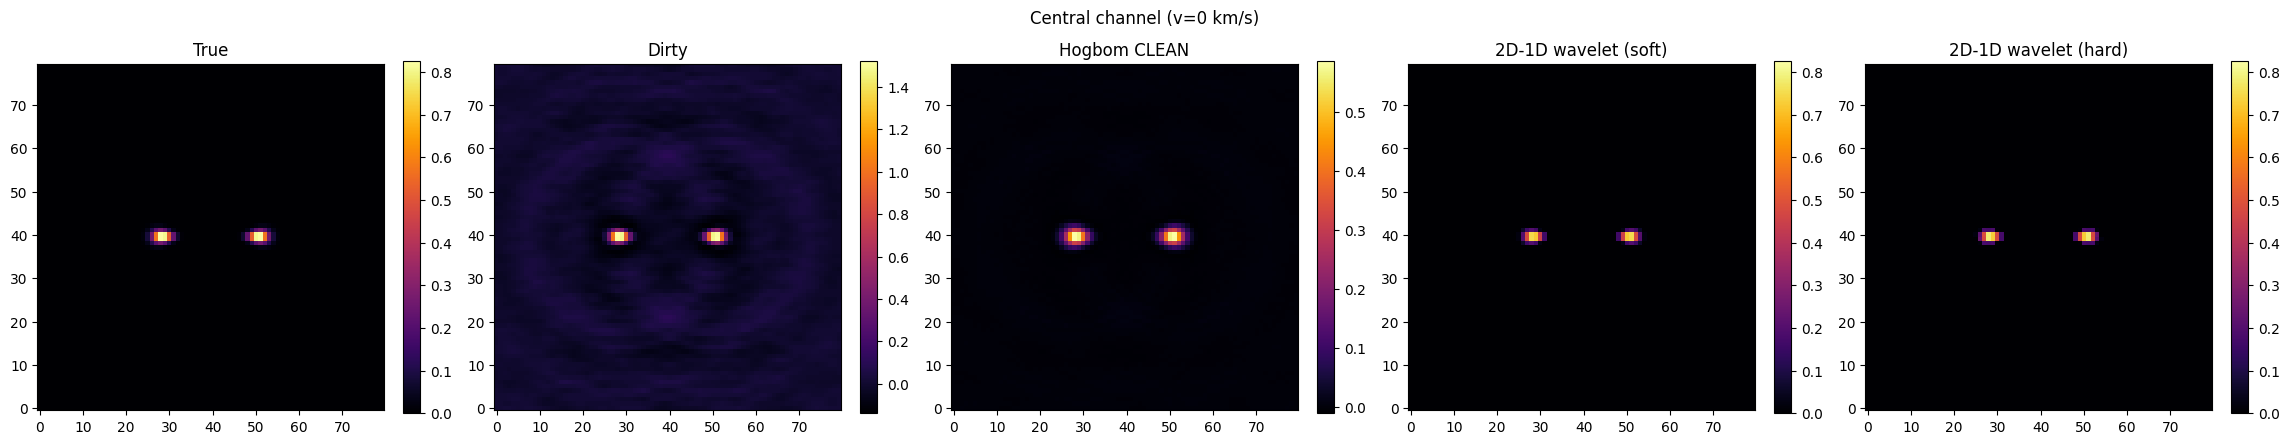

In [16]:
def compare_panels(k, title):
    fig, axs = plt.subplots(1, 5, figsize=(23, 4.4))
    vmax = max(cube[k].max(), model_soft[k].max(), model_hard[k].max(), 1e-6)
    panels = [
        ('True', cube[k], 0),
        ('Dirty', dirty_cube[k], None),
        ('Hogbom CLEAN', restored_clean[k], None),
        ('2D-1D wavelet (soft)', model_soft[k], 0),
        ('2D-1D wavelet (hard)', model_hard[k], 0),
    ]
    for ax, (name, img, vmin) in zip(axs, panels):
        im = ax.imshow(img, origin='lower', cmap='inferno',
                        vmin=vmin, vmax=vmax if vmin is not None else None)
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

compare_panels(center_channel, f'Central channel (v={velocities[center_channel]:.0f} km/s)')

channel 7 (v=-186 km/s) blob counts at a shared 0.291 threshold:
  true          = 2
  dirty         = 2
  Hogbom CLEAN  = 2
  wavelet, soft = 2
  wavelet, hard = 2


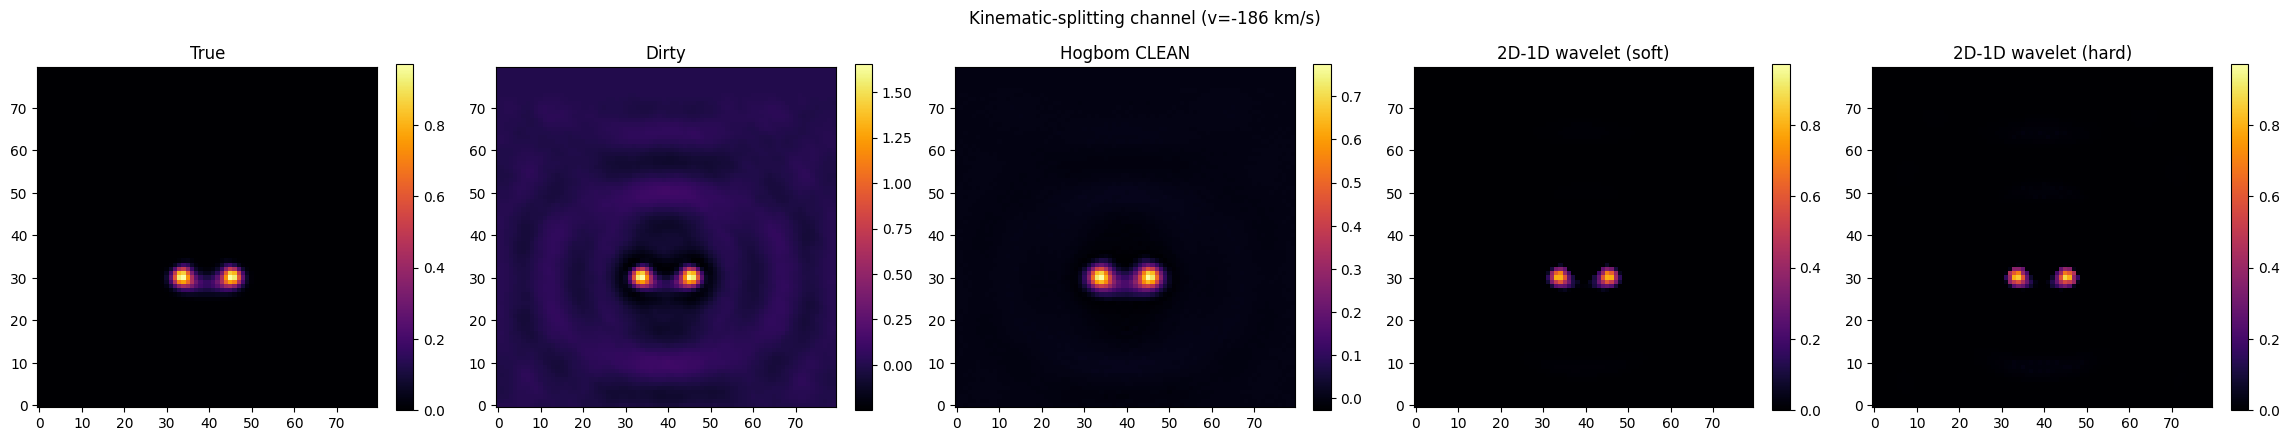

In [17]:
# Find the channel with the widest true blob separation for the clearest
# demonstration of recovering the kinematic splitting.
best_k = None
for k in range(nz):
    peak = cube[k].max()
    if peak < 0.3 * cube.max():
        continue
    n_blobs, _ = count_blobs(cube[k], 0.3 * peak)
    if n_blobs >= 2:
        best_k = k
        break
split_k = best_k if best_k is not None else center_channel

# With no noise in this run, one shared threshold (a fraction of the true
# peak) is fair across all four maps -- unlike the earlier noisy comparison,
# there's no separate "raw noise floor" confound to route around here, so
# a single detection convention for every method is enough.
thr = 0.3 * cube[split_k].max()
n_true, _ = count_blobs(cube[split_k], thr)
n_dirty, _ = count_blobs(np.clip(dirty_cube[split_k], 0, None), thr)
n_clean, _ = count_blobs(np.clip(restored_clean[split_k], 0, None), thr)
n_soft, _ = count_blobs(model_soft[split_k], thr)
n_hard, _ = count_blobs(model_hard[split_k], thr)
print(f'channel {split_k} (v={velocities[split_k]:.0f} km/s) blob counts at a shared {thr:.3g} threshold:')
print(f'  true          = {n_true}')
print(f'  dirty         = {n_dirty}')
print(f'  Hogbom CLEAN  = {n_clean}')
print(f'  wavelet, soft = {n_soft}')
print(f'  wavelet, hard = {n_hard}')

compare_panels(split_k, f'Kinematic-splitting channel (v={velocities[split_k]:.0f} km/s)')

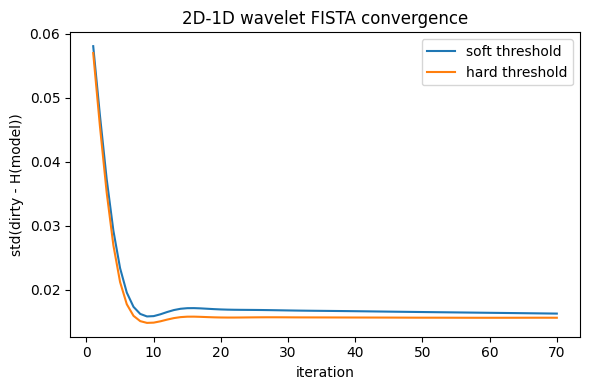

In [18]:
plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(history_soft['residual_std']) + 1), history_soft['residual_std'], label='soft threshold')
plt.plot(np.arange(1, len(history_hard['residual_std']) + 1), history_hard['residual_std'], label='hard threshold')
plt.xlabel('iteration')
plt.ylabel('std(dirty - H(model))')
plt.title('2D-1D wavelet FISTA convergence')
plt.legend()
plt.tight_layout()
plt.show()

## Takeaways

- The dirty beam's sidelobes (not a clean Gaussian PSF -- real interferometric
  dirty beams never are) visibly corrupt the central channel with negative
  bowls and ripples, and even redistribute total flux -- the dirty cube's
  total flux can come out *negative* (see the printed numbers above), despite
  every true voxel being non-negative, purely from sidelobe structure.
- **With no noise in this run, CLEAN is a much stronger baseline than in the
  earlier noisy comparison** (see `README.md` for that version's numbers).
  CLEAN's restored image still adds its leftover residual back unfiltered,
  but with nothing to overfit, it can clean very deep (thousands of
  components) with no real downside, and gets most of the way back to the
  true cube. This isolates what CLEAN's weak point actually is: it is not
  fitting extended structure with delta functions per se, it is doing so
  *while also* not being able to distinguish signal from noise the way the
  wavelet thresholding does -- so its disadvantage shows up specifically
  under realistic noise, not here.
- **Soft vs. hard threshold is still a real bias/variance trade-off even
  without noise.** Hard thresholding keeps surviving coefficients at full
  amplitude (unbiased), recovering more flux; soft thresholding shrinks
  every coefficient by the threshold amount, systematically undershooting
  peak brightness in exchange for a smoother, less speckled reconstruction.
  Check the printed flux/RMSE numbers and the kinematic-splitting channel's
  blob count above for how that plays out in this specific run.
- All three deconvolution outputs' recovered flux still falls short of the
  true flux. This is expected, not a bug: the dirty beam has ~zero response
  at the zero-spacing (DC) mode (`beam.sum() ~ 0`, verified above), so that
  flux is fundamentally unconstrained by the data for *any* deconvolution
  method -- noise or no noise. See `README.md` for how `Deconvolver2D1D`
  handles that null space explicitly (zeroing the coarsest wavelet
  sub-band instead of leaving it free, which otherwise makes the FISTA
  iteration diverge); CLEAN's small loop gain simply keeps it from ever
  exploring that direction in the first place.